In [1]:

import numpy as np 
import pandas as pd 
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
import xgboost
from sklearn.feature_selection import mutual_info_regression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import Pool, CatBoostRegressor, cv
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_csv('E-commerce.csv', encoding='latin')
data.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


In [3]:
data = data[['Product_Category', 'Product', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Shipping_Cost']]

# data = data[['Sales','Quantity', 'Discount', 'Profit', 'Shipping_Cost']]

In [4]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Assuming df is your DataFrame and 'Product_Category' is the column you want to encode
label_encoder_product_category = LabelEncoder()
data['Product_Category_Label'] = label_encoder_product_category.fit_transform(data['Product_Category'])

# Save the label encoder to a file
joblib.dump(label_encoder_product_category, 'label_encoder_product_category.pkl')


# Assuming df is your DataFrame and 'Product_Category' is the column you want to encode
label_encoder_product_type = LabelEncoder()
data['Product_type_Label'] = label_encoder_product_type.fit_transform(data['Product'])

# Save the label encoder to a file
joblib.dump(label_encoder_product_type, 'label_encoder_product_type.pkl')



['label_encoder_product_type.pkl']

In [5]:
data.head()

,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Product_Category_Label,Product_type_Label
0,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,0,7
1,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,0,10
2,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,0,5
3,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,0,4
4,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,0,39


In [6]:
data['Product_Category_Label'].unique()

array([0, 2, 1, 3])

In [7]:
label_mapping_dict = dict(zip(label_encoder_product_category.classes_, label_encoder_product_category.transform(label_encoder_product_category.classes_)))
label_mapping_dict

{'Auto & Accessories': 0, 'Electronic': 1, 'Fashion': 2, 'Home & Furniture': 3}

In [8]:
# label_mapping_dict = dict(zip(label_encoder_product_type.classes_, label_encoder_product_type.transform(label_encoder_product_type.classes_)))
# label_mapping_dict

label_mapping_dict = {encoded_value: label for label, encoded_value in zip(label_encoder_product_type.classes_, label_encoder_product_type.transform(label_encoder_product_type.classes_))}
label_mapping_dict

{0: 'Apple Laptop',
 1: 'Bed Sheets',
 2: 'Beds',
 3: 'Bike Tyres',
 4: 'Car & Bike Care',
 5: 'Car Body Covers',
 6: 'Car Mat',
 7: 'Car Media Players',
 8: 'Car Pillow & Neck Rest',
 9: 'Car Seat Covers',
 10: 'Car Speakers',
 11: 'Casula Shoes',
 12: 'Curtains',
 13: 'Dinner Crockery',
 14: 'Dinning Tables',
 15: 'Fans',
 16: 'Formal Shoes',
 17: 'Fossil Watch',
 18: 'Iron',
 19: 'Jeans',
 20: 'Keyboard',
 21: 'LCD',
 22: 'LED',
 23: 'Mixer/Juicer',
 24: 'Mouse',
 25: 'Running Shoes',
 26: 'Samsung Mobile',
 27: 'Shirts',
 28: 'Shoe Rack',
 29: 'Sneakers',
 30: 'Sofa Covers',
 31: 'Sofas',
 32: 'Speakers',
 33: 'Sports Wear',
 34: 'Suits',
 35: 'T - Shirts',
 36: 'Tablet',
 37: 'Titak watch',
 38: 'Towels',
 39: 'Tyre',
 40: 'Umbrellas',
 41: 'Watch'}

In [9]:
# prod.cat , pro.name,quanti
data.columns

Index(['Product_Category', 'Product', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping_Cost', 'Product_Category_Label',
       'Product_type_Label'],
      dtype='object')

In [10]:
data.shape

(51290, 9)

**Handling NaN values**

In [11]:

data.isna().sum()

Product_Category          0
Product                   0
Sales                     1
Quantity                  2
Discount                  1
Profit                    0
Shipping_Cost             1
Product_Category_Label    0
Product_type_Label        0
dtype: int64

In [12]:
data = data.dropna()

In [13]:
data.shape

(51285, 9)

In [14]:
data.isnull().sum()


Product_Category          0
Product                   0
Sales                     0
Quantity                  0
Discount                  0
Profit                    0
Shipping_Cost             0
Product_Category_Label    0
Product_type_Label        0
dtype: int64

**Unique values in df**

In [15]:
#Unique values in the dataframe
data.nunique()

Product_Category            4
Product                    42
Sales                      39
Quantity                    5
Discount                    5
Profit                    391
Shipping_Cost             153
Product_Category_Label      4
Product_type_Label         42
dtype: int64

In [16]:
# print(data.describe())
# print(data.info())
data.describe()

,Sales,Quantity,Discount,Profit,Shipping_Cost,Product_Category_Label,Product_type_Label
count,51285.000000,51285.000000,51285.000000,51285.000000,51285.000000,51285.000000,51285.000000
mean,152.340548,2.502935,0.303833,70.404395,7.041427,1.955874,21.894999
std,66.492851,1.511834,0.131024,48.728944,4.871768,0.967847,11.832106
min,33.000000,1.000000,0.100000,0.500000,0.100000,0.000000,0.000000
25%,85.000000,1.000000,0.200000,24.900000,2.500000,2.000000,12.000000
50%,133.000000,2.000000,0.300000,59.900000,6.000000,2.000000,25.000000
75%,218.000000,4.000000,0.400000,118.400000,11.800000,3.000000,33.000000
max,250.000000,5.000000,0.500000,167.500000,16.800000,3.000000,41.000000


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51285 entries, 0 to 51289
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Product_Category        51285 non-null  object 
 1   Product                 51285 non-null  object 
 2   Sales                   51285 non-null  float64
 3   Quantity                51285 non-null  float64
 4   Discount                51285 non-null  float64
 5   Profit                  51285 non-null  float64
 6   Shipping_Cost           51285 non-null  float64
 7   Product_Category_Label  51285 non-null  int32  
 8   Product_type_Label      51285 non-null  int32  
dtypes: float64(5), int32(2), object(2)
memory usage: 3.5+ MB


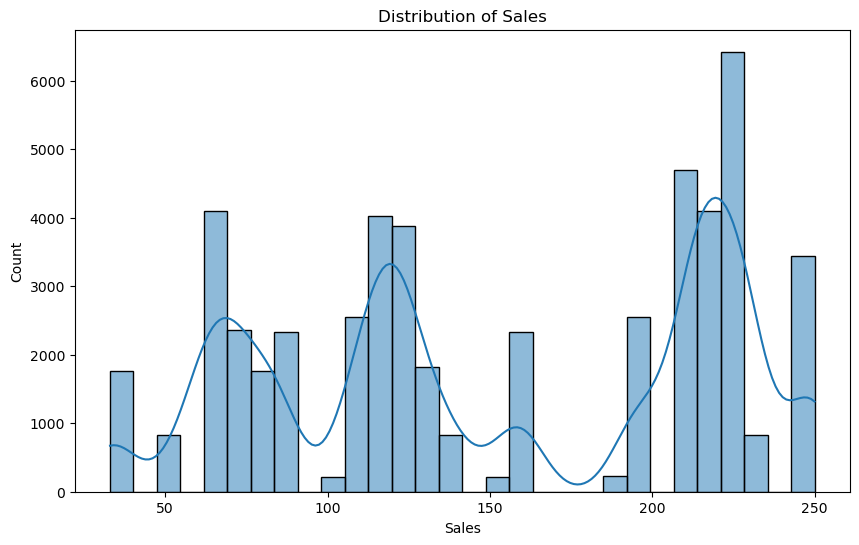

In [18]:
# Visualize the target variable (Sales)
plt.figure(figsize=(10, 6))
sns.histplot(data['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.show()

In [19]:

# Correlation matrix
#correlation_matrix = data.corr()
#plt.figure(figsize=(12, 8))
#sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
#plt.title('Correlation Matrix')
#plt.show()

In [20]:
X=data[['Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Product_Category_Label', 'Product_type_Label']]

X=X.fillna(-1)
print(X.columns)
# categorical_features_indices =[0,1]
y=data['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42)

X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, 
                                                    random_state=52)

Index(['Quantity', 'Discount', 'Profit', 'Shipping_Cost',
       'Product_Category_Label', 'Product_type_Label'],
      dtype='object')


In [21]:
X_train

,Quantity,Discount,Profit,Shipping_Cost,Product_Category_Label,Product_type_Label
15879,1.0,0.2,107.5,10.8,0,39
19565,3.0,0.2,42.2,4.2,1,32
14217,5.0,0.5,1.8,0.2,2,34
9742,5.0,0.5,11.5,1.2,2,11
24599,1.0,0.3,141.2,14.1,2,37
...,...,...,...,...,...,...
21907,5.0,0.5,67.0,6.7,2,27
46671,1.0,0.2,17.0,1.7,3,12
41277,5.0,0.3,23.7,2.4,2,11
34967,3.0,0.1,26.0,2.6,3,2


In [22]:
# X

In [23]:
def perform_model_lr(X_train, y_train,X_valid, y_valid,X_test, y_test):
    model_lr = LinearRegression()
    
    model_lr.fit(
        X_train, y_train)
    
    print("RMSE on training data: "+ model_lr.score(X_train, y_train).astype(str))
    print("RMSE on test data: "+ model_lr.score(X_test, y_test).astype(str))
    
    return model_lr
model_lr = perform_model_lr(X_train, y_train,X_valid, y_valid,X_test, y_test)

RMSE on training data: 0.866682577402271
RMSE on test data: 0.869620352197283


In [24]:
model_lr

LinearRegression()

In [25]:
import pickle
pickle.dump(model_lr, open('lr_model_new2.pkl', 'wb')) #svm has the highest accuracy

In [26]:
import pickle
import numpy as np
pickled_model = pickle.load(open('lr_model_new2.pkl', 'rb'))
prediction = pickled_model.predict(np.array([[20,30,1.0,2.5,47.0,8.6]]))
prediction_str = f'The predicted value is: {prediction[0]:.2f}'
prediction_str

C:\Users\siddh\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


'The predicted value is: 1122.18'

In [ ]:
 run app.py

 * Serving Flask app 'app'
 * Debug mode: on


 * Running on http://127.0.0.1:5003
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)
